# Multi-condition iMAT

This notebook extends the single-sample iMAT example with a more structured
multi-condition setup.

The goal is to show when `MultiSampleIMAT` can differ from running iMAT
separately per sample. We build a branched network where each condition weakly
favors a different branch, then compare:

- multi-sample iMAT with no cross-sample regularization (`lambda_reg=0`)
- multi-sample iMAT with structured regularization (`lambda_reg=0.5`)
- two independent single-sample iMAT runs (`lambda_reg=0.5`)


Installed version: v1.0.0b3.post1.dev0+048af53c
Available backends: CVXPY v1.8.1, PICOS v2.6.2
Default backend (corneto.opt): CVXPY
Installed solvers: CVXOPT, GLPK, GLPK_MI, HIGHS, SCIP, SCIPY
Plot backend (default): auto -> graphviz
Available plot backends: graphviz v0.20.3; networkx v3.6+mpl v3.10.8; graphviz-wasm
Installed path: /Users/pablorodriguezmier/Documents/work/projects/corneto/corneto
Repository: https://github.com/saezlab/corneto
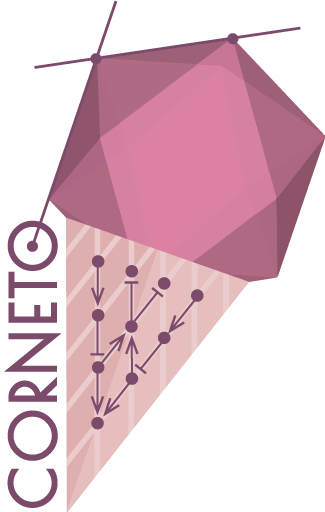

In [1]:
import numpy as np
import pandas as pd

import corneto as cn
from corneto.methods.future.imat import MultiSampleIMAT

cn.info()

In [2]:
G = cn.Graph()

# Uptake
G.add_edge((), "A", id="EX_A", default_lb=0, default_ub=10)

# Branch 1
G.add_edge("A", "B", id="R_AB", default_lb=0, default_ub=100)
G.add_edge("B", "C", id="R_BC", default_lb=0, default_ub=100)

# Branch 2
G.add_edge("A", "D", id="R_AD", default_lb=0, default_ub=100)
G.add_edge("D", "C", id="R_DC", default_lb=0, default_ub=100)

# Shared trunk to objective
G.add_edge("C", "E", id="R_CE", default_lb=0, default_ub=100)
G.add_edge("E", "F", id="R_EF", default_lb=0, default_ub=100)
G.add_edge("F", (), id="BIOMASS", default_lb=0, default_ub=100)

# Side drains to make the topology less trivial
G.add_edge("B", "X", id="R_BX", default_lb=0, default_ub=100)
G.add_edge("X", (), id="R_X_sink", default_lb=0, default_ub=100)
G.add_edge("D", "Y", id="R_DY", default_lb=0, default_ub=100)
G.add_edge("Y", (), id="R_Y_sink", default_lb=0, default_ub=100)

pd.DataFrame(
    {
        "edge_index": range(G.num_edges),
        "reaction_id": [G.get_attr_edge(i).get("id") for i in range(G.num_edges)],
    }
)

,edge_index,reaction_id
0,0,EX_A
1,1,R_AB
2,2,R_BC
3,3,R_AD
4,4,R_DC
5,5,R_CE
6,6,R_EF
7,7,BIOMASS
8,8,R_BX
9,9,R_X_sink


In [3]:
w = 0.2  # weak, conflicting evidence for alternative branches

scores_condition_1 = {
    "R_AB": +w,
    "R_BC": +w,
    "R_AD": -w,
    "R_DC": -w,
    "R_BX": -0.1,
    "R_DY": -0.1,
}

scores_condition_2 = {
    "R_AB": -w,
    "R_BC": -w,
    "R_AD": +w,
    "R_DC": +w,
    "R_BX": -0.1,
    "R_DY": -0.1,
}


def sample_from_scores(scores):
    sample = {"BIOMASS": {"role": "objective"}}
    for rid, value in scores.items():
        sample[rid] = {"mapping": "edge", "value": float(value)}
    return sample


multi_data = cn.Data.from_cdict(
    {
        "condition_1": sample_from_scores(scores_condition_1),
        "condition_2": sample_from_scores(scores_condition_2),
    }
)

single_data_c1 = cn.Data.from_cdict({"condition_1": sample_from_scores(scores_condition_1)})
single_data_c2 = cn.Data.from_cdict({"condition_2": sample_from_scores(scores_condition_2)})

In [4]:
# Multi-sample without cross-sample coupling
imat_multi_uncoupled = MultiSampleIMAT(lambda_reg=0.0, eps=1e-3)
P_multi_uncoupled = imat_multi_uncoupled.build(G, multi_data)
P_multi_uncoupled.solve(solver="highs")

# Multi-sample with structured regularization across samples
imat_multi_coupled = MultiSampleIMAT(lambda_reg=0.5, eps=1e-3)
P_multi_coupled = imat_multi_coupled.build(G, multi_data)
P_multi_coupled.solve(solver="highs")

# Independent single-sample runs (same lambda as coupled run)
imat_single_c1 = MultiSampleIMAT(lambda_reg=0.5, eps=1e-3)
P_single_c1 = imat_single_c1.build(G, single_data_c1)
P_single_c1.solve(solver="highs")

imat_single_c2 = MultiSampleIMAT(lambda_reg=0.5, eps=1e-3)
P_single_c2 = imat_single_c2.build(G, single_data_c2)
P_single_c2.solve(solver="highs")

Problem(Minimize(Expression(AFFINE, UNKNOWN, ())), [Inequality(Constant(CONSTANT, ZERO, (12,))), Inequality(Variable((12,), _flow)), Equality(Expression(AFFINE, UNKNOWN, (8,)), Constant(CONSTANT, ZERO, ())), Inequality(Expression(AFFINE, ZERO, (12,))), Inequality(Variable((12,), _flow)), Inequality(Expression(AFFINE, NONNEGATIVE, (6,))), Equality(Expression(AFFINE, NONNEGATIVE, (6,)), Constant(CONSTANT, ZERO, ())), Inequality(Expression(AFFINE, NONNEGATIVE, (6,))), Inequality(Expression(AFFINE, UNKNOWN, (6,))), Inequality(Expression(AFFINE, NONNEGATIVE, (6,)))])

In [5]:
reactions = ["R_AB", "R_BC", "R_AD", "R_DC", "BIOMASS"]
idx = {rid: next(iter(G.get_edges_by_attr("id", rid))) for rid in reactions}

summary = pd.DataFrame(
    {
        "reaction": reactions,
        "multi_lambda0_c1": [float(P_multi_uncoupled.expr.flow[idx[r], 0].value) for r in reactions],
        "multi_lambda0_c2": [float(P_multi_uncoupled.expr.flow[idx[r], 1].value) for r in reactions],
        "multi_lambda0.5_c1": [float(P_multi_coupled.expr.flow[idx[r], 0].value) for r in reactions],
        "multi_lambda0.5_c2": [float(P_multi_coupled.expr.flow[idx[r], 1].value) for r in reactions],
        "single_c1_lambda0.5": [float(P_single_c1.expr.flow[idx[r]].value) for r in reactions],
        "single_c2_lambda0.5": [float(P_single_c2.expr.flow[idx[r]].value) for r in reactions],
    }
)

summary

,reaction,multi_lambda0_c1,multi_lambda0_c2,multi_lambda0.5_c1,multi_lambda0.5_c2,single_c1_lambda0.5,single_c2_lambda0.5
0,R_AB,10.0,-0.0,10.0,10.0,10.0,-0.0
1,R_BC,10.0,0.0,10.0,10.0,10.0,0.0
2,R_AD,-0.0,10.0,-0.0,-0.0,-0.0,10.0
3,R_DC,0.0,10.0,0.0,0.0,0.0,10.0
4,BIOMASS,10.0,10.0,10.0,10.0,10.0,10.0


In [6]:
def branch_label(ab_flux, ad_flux, tol=1e-6):
    ab_on = abs(ab_flux) > tol
    ad_on = abs(ad_flux) > tol
    if ab_on and not ad_on:
        return "branch_1 (A->B->C)"
    if ad_on and not ab_on:
        return "branch_2 (A->D->C)"
    if ab_on and ad_on:
        return "both"
    return "none"


branch_usage = pd.DataFrame(
    {
        "setting": [
            "multi lambda=0 (condition_1)",
            "multi lambda=0 (condition_2)",
            "multi lambda=0.5 (condition_1)",
            "multi lambda=0.5 (condition_2)",
            "single condition_1 lambda=0.5",
            "single condition_2 lambda=0.5",
        ],
        "selected_branch": [
            branch_label(
                P_multi_uncoupled.expr.flow[idx["R_AB"], 0].value, P_multi_uncoupled.expr.flow[idx["R_AD"], 0].value
            ),
            branch_label(
                P_multi_uncoupled.expr.flow[idx["R_AB"], 1].value, P_multi_uncoupled.expr.flow[idx["R_AD"], 1].value
            ),
            branch_label(
                P_multi_coupled.expr.flow[idx["R_AB"], 0].value, P_multi_coupled.expr.flow[idx["R_AD"], 0].value
            ),
            branch_label(
                P_multi_coupled.expr.flow[idx["R_AB"], 1].value, P_multi_coupled.expr.flow[idx["R_AD"], 1].value
            ),
            branch_label(P_single_c1.expr.flow[idx["R_AB"]].value, P_single_c1.expr.flow[idx["R_AD"]].value),
            branch_label(P_single_c2.expr.flow[idx["R_AB"]].value, P_single_c2.expr.flow[idx["R_AD"]].value),
        ],
    }
)

single_c1_branch = branch_usage.loc[
    branch_usage["setting"] == "single condition_1 lambda=0.5", "selected_branch"
].item()
single_c2_branch = branch_usage.loc[
    branch_usage["setting"] == "single condition_2 lambda=0.5", "selected_branch"
].item()
multi_coupled_c1_branch = branch_usage.loc[
    branch_usage["setting"] == "multi lambda=0.5 (condition_1)", "selected_branch"
].item()
multi_coupled_c2_branch = branch_usage.loc[
    branch_usage["setting"] == "multi lambda=0.5 (condition_2)", "selected_branch"
].item()

# Sanity checks for the tutorial narrative.
assert single_c1_branch != single_c2_branch, "Single-sample runs should select different branches."
assert multi_coupled_c1_branch == multi_coupled_c2_branch, "Coupled multi-sample run should align branch usage."

branch_usage

,setting,selected_branch
0,multi lambda=0 (condition_1),branch_1 (A->B->C)
1,multi lambda=0 (condition_2),branch_2 (A->D->C)
2,multi lambda=0.5 (condition_1),branch_1 (A->B->C)
3,multi lambda=0.5 (condition_2),branch_1 (A->B->C)
4,single condition_1 lambda=0.5,branch_1 (A->B->C)
5,single condition_2 lambda=0.5,branch_2 (A->D->C)


With weak and conflicting evidence, adding cross-sample structured
regularization (`lambda_reg=0.5`) can favor a shared active subnetwork across
conditions. Running each condition independently does not enforce this coupling,
so single-sample runs can keep different branches.

The assertions above make this expectation explicit in the tutorial.

## Per-Condition Fit And Shared Reactions

We quantify iMAT fit per condition as weighted agreement with reaction evidence:

- positive score: better if reaction is active
- negative score: better if reaction is inactive

Then we report shared and condition-specific active reactions.

In [7]:
all_edge_ids = [G.get_attr_edge(i).get("id") for i in range(G.num_edges)]
edge_index_by_id = {rid: i for i, rid in enumerate(all_edge_ids)}


def get_active_ids(problem, condition=None, tol=1e-6):
    if condition is None:
        flow = np.asarray(problem.expr.flow.value)
    else:
        flow = np.asarray(problem.expr.flow.value)[:, condition]
    active_idx = np.where(np.abs(flow) > tol)[0]
    return {all_edge_ids[i] for i in active_idx}


def weighted_fit(problem, scores, condition=None, tol=1e-6):
    if condition is None:
        flow = np.asarray(problem.expr.flow.value)
    else:
        flow = np.asarray(problem.expr.flow.value)[:, condition]

    total = 0.0
    matched = 0.0
    for rid, score in scores.items():
        i = edge_index_by_id[rid]
        active = abs(float(flow[i])) > tol
        weight = abs(float(score))
        ok = (score > 0 and active) or (score < 0 and not active)
        total += weight
        if ok:
            matched += weight

    return {
        "matched_weight": matched,
        "total_weight": total,
        "fit_ratio": matched / total if total > 0 else np.nan,
    }


fit_rows = []
for label, problem, c1_idx, c2_idx in [
    ("multi lambda=0", P_multi_uncoupled, 0, 1),
    ("multi lambda=0.5", P_multi_coupled, 0, 1),
    ("single lambda=0.5", None, None, None),
]:
    if problem is not None:
        c1 = weighted_fit(problem, scores_condition_1, condition=c1_idx)
        c2 = weighted_fit(problem, scores_condition_2, condition=c2_idx)
    else:
        c1 = weighted_fit(P_single_c1, scores_condition_1)
        c2 = weighted_fit(P_single_c2, scores_condition_2)

    fit_rows.append(
        {
            "setting": label,
            "condition_1_fit_ratio": c1["fit_ratio"],
            "condition_2_fit_ratio": c2["fit_ratio"],
            "mean_fit_ratio": (c1["fit_ratio"] + c2["fit_ratio"]) / 2,
        }
    )

fit_table = pd.DataFrame(fit_rows)
fit_table

,setting,condition_1_fit_ratio,condition_2_fit_ratio,mean_fit_ratio
0,multi lambda=0,1.0,1.0,1.0
1,multi lambda=0.5,1.0,0.2,0.6
2,single lambda=0.5,1.0,1.0,1.0


In [8]:
def shared_unique_summary(active_c1, active_c2, setting):
    shared = sorted(active_c1 & active_c2)
    only_c1 = sorted(active_c1 - active_c2)
    only_c2 = sorted(active_c2 - active_c1)
    return {
        "setting": setting,
        "n_shared": len(shared),
        "shared": shared,
        "only_condition_1": only_c1,
        "only_condition_2": only_c2,
    }


multi_coupled_active_c1 = get_active_ids(P_multi_coupled, condition=0)
multi_coupled_active_c2 = get_active_ids(P_multi_coupled, condition=1)

single_active_c1 = get_active_ids(P_single_c1)
single_active_c2 = get_active_ids(P_single_c2)

shared_table = pd.DataFrame(
    [
        shared_unique_summary(multi_coupled_active_c1, multi_coupled_active_c2, "multi lambda=0.5"),
        shared_unique_summary(single_active_c1, single_active_c2, "single lambda=0.5"),
    ]
)

shared_table

,setting,n_shared,shared,only_condition_1,only_condition_2
0,multi lambda=0.5,6,"[BIOMASS, EX_A, R_AB, R_BC, R_CE, R_EF]",[],[]
1,single lambda=0.5,4,"[BIOMASS, EX_A, R_CE, R_EF]","[R_AB, R_BC]","[R_AD, R_DC]"


In [9]:
# Optional plotting if Graphviz is available
try:
    active_multi_c1 = np.abs(P_multi_coupled.expr.flow.value[:, 0]) > 1e-6
    active_multi_c2 = np.abs(P_multi_coupled.expr.flow.value[:, 1]) > 1e-6

    G.edge_subgraph(active_multi_c1).plot(graph_attr={"rankdir": "LR", "center": "1"})
    G.edge_subgraph(active_multi_c2).plot(graph_attr={"rankdir": "LR", "center": "1"})
except Exception as e:
    print(f"Plot skipped: {e}")